In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

df = pd.read_json("../data/dataset.json")

### LISTA DE TODAS LAS ETIQUETAS (TAGS) ÚNICAS

In [20]:


todos_los_tags = [tag for lista in df['tags'] for tag in lista]
conteo_tags = Counter(todos_los_tags)

df_tags = pd.DataFrame(conteo_tags.items(), columns=['Tag', 'Cantidad']).sort_values(by='Cantidad', ascending=False).reset_index(drop=True)

total_apariciones = df_tags['Cantidad'].sum()
df_tags['Porcentaje'] = (df_tags['Cantidad'] / total_apariciones * 100).round(2).astype(str) + '%'

display(df_tags)

,Tag,Cantidad,Porcentaje
0,python,99,31.73%
1,javascript,50,16.03%
2,webdev,31,9.94%
3,r,17,5.45%
4,react,12,3.85%
5,productivity,9,2.88%
6,ai,8,2.56%
7,showdev,7,2.24%
8,beginners,7,2.24%
9,frontend,6,1.92%


## TOP 10 DE TAGS

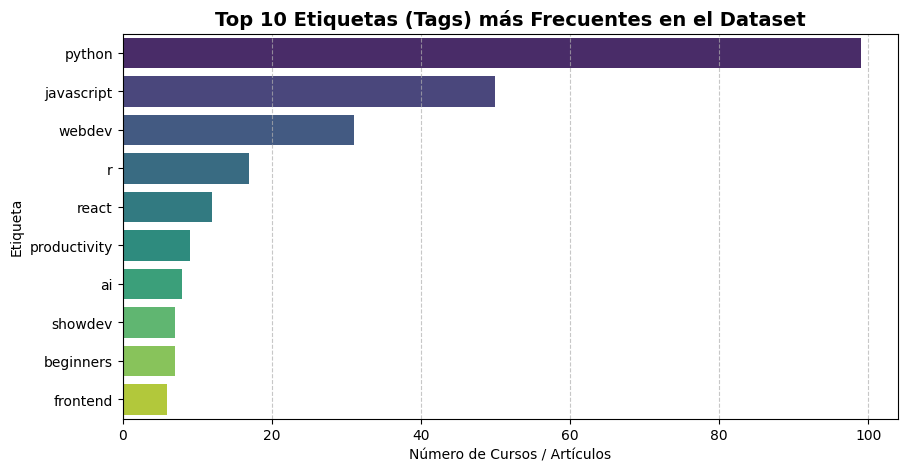

In [21]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_tags.head(10),
    x='Cantidad',
    y='Tag',
    hue='Tag',
    palette='viridis',
    legend=False
)
plt.title('Top 10 Etiquetas (Tags) más Frecuentes en el Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Número de Cursos / Artículos')
plt.ylabel('Etiqueta')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## DISTRIBUCIÓN DE LONGITUD DE DESCRIPCIÓN

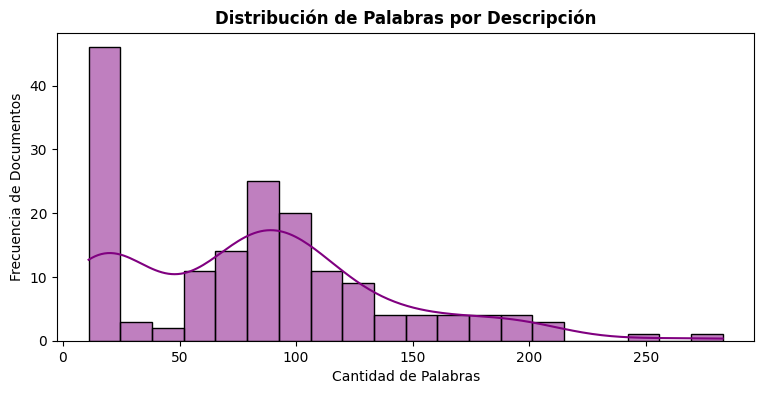


--- Resumen Estadístico de las Descripciones ---
count    166.000000
mean      82.180723
std       56.016479
min       11.000000
25%       20.000000
50%       83.000000
75%      109.000000
max      283.000000
Name: cant_palabras_desc, dtype: float64


In [22]:
df['cant_palabras_desc'] = df['description'].fillna('').apply(lambda x: len(str(x).split()))

plt.figure(figsize=(9, 4))
sns.histplot(df['cant_palabras_desc'], bins=20, kde=True, color='purple')
plt.title('Distribución de Palabras por Descripción', fontsize=12, fontweight='bold')
plt.xlabel('Cantidad de Palabras')
plt.ylabel('Frecuencia de Documentos')
plt.show()

print("\n--- Resumen Estadístico de las Descripciones ---")
print(df['cant_palabras_desc'].describe())

plt.show()

### Interpretación del gráfico
* **Comportamiento Bimodal:** El dataset cuenta con un total de **166** documentos. El pico más alto (a la izquierda) concentra **46** registros con descripciones muy cortas (25 palabras o menos). El segundo grupo se estabiliza alrededor de la mediana del dataset, la cual es de **83** palabras por descripción.
* **Tendencia Central:** El promedio general (media) es de **82.2** palabras.
* **Presencia de Outliers:** Existe una asimetría positiva hacia la derecha debido a un pequeño volumen de textos atípicos muy extensos que alcanzan un máximo de **283** palabras.